In [183]:
import pandas as pd
import matplotlib.pyplot as plt

In [184]:
# Path to your event log CSV
log_path = "D:/Projects/Big/opra/data/logs/AcademicCredentials/AcademicCredentials_train.csv"

# Read log
df_log = pd.read_csv(log_path)

# Detect case id column
if "case_id" in df_log.columns:
    case_col = "case_id"
elif "case" in df_log.columns:
    case_col = "case"

else:
    raise ValueError("No case id column found. Expected 'caseid' or 'case'.")

# Group by case id (number of events per case)
cases_grouped = df_log.groupby(case_col).size().reset_index(name="num_events")

# Number of cases
num_cases = cases_grouped.shape[0]
print(f"Number of cases: {num_cases}")

# cases_grouped.head()

model_metrics_path = "./data/training_runs/AcademicCredentials_DDPS_p80_800_400"

Number of cases: 398


In [185]:
df_agents = pd.read_csv(f"{model_metrics_path}/update_metrics.csv")

df_agents.head()

,update,episode,policy_loss,value_loss,entropy,total_loss,approx_kl,clip_fraction
0,1,1,-0.064347,0.499709,5.463435,0.380728,NaN,NaN
1,2,2,-0.043999,0.497318,5.454400,0.398776,NaN,NaN
2,3,3,-0.031060,0.493541,5.435419,0.408127,NaN,NaN
3,4,4,-0.019577,0.489364,5.432325,0.415464,NaN,NaN
4,5,5,-0.008240,0.484829,5.449335,0.422096,NaN,NaN


In [186]:
df_episode = pd.read_csv(f"{model_metrics_path}/episode_metrics.csv")

df_episode.head()

,episode,total_reward,num_steps,num_cases,num_compliant,sla_compliance_rate,avg_cycle_time,median_cycle_time,std_cycle_time,min_cycle_time,max_cycle_time,p75_cycle_time,p90_cycle_time,p95_cycle_time,episode_duration_sec,resource_utilization_cv
0,1,289.269777,5934,800,580,0.72500,907512.680382,414236.33,1.262250e+06,0.0,10028679.66,1.313452e+06,2.564757e+06,3.633986e+06,15.160752,NaN
1,2,309.067766,5792,800,596,0.74500,878978.660423,337154.33,1.239697e+06,0.0,8470714.00,1.211099e+06,2.688717e+06,3.652666e+06,17.002537,NaN
2,3,324.947617,5970,800,607,0.75875,840585.351809,270343.83,1.228644e+06,0.0,7900053.00,1.112936e+06,2.404353e+06,3.663791e+06,13.844517,NaN
3,4,328.917808,5894,800,611,0.76375,857129.684492,336915.50,1.288817e+06,0.0,10753028.00,1.117071e+06,2.380660e+06,3.633756e+06,13.828236,NaN
4,5,345.159606,6011,800,601,0.75125,848936.933176,349389.83,1.204141e+06,0.0,8573210.00,1.179976e+06,2.230872e+06,3.529982e+06,16.547650,NaN


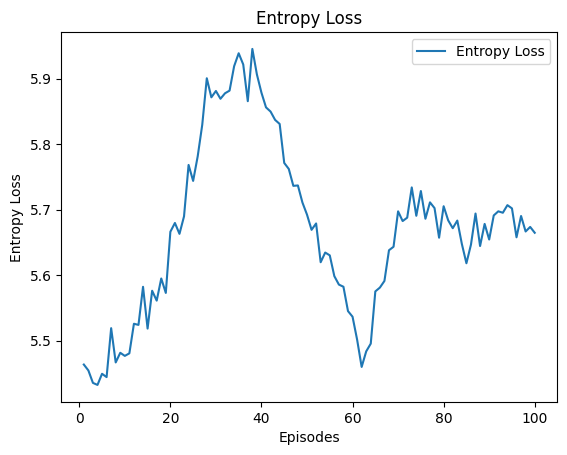

In [187]:
plt.plot(df_agents["episode"], df_agents['entropy'], label="Entropy Loss")
plt.xlabel("Episodes")
plt.ylabel("Entropy Loss")
plt.title("Entropy Loss")
plt.legend()
plt.show()

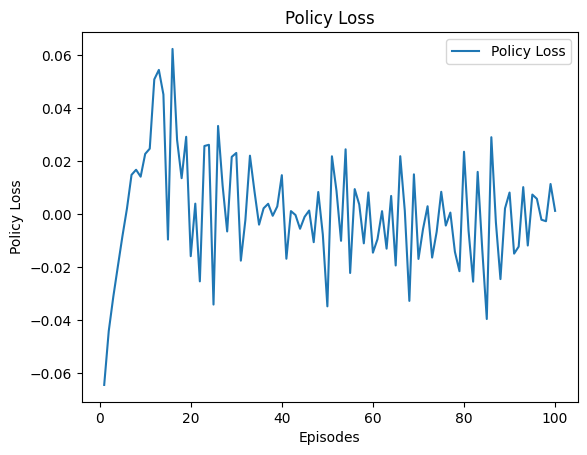

In [188]:
plt.plot(df_agents["episode"], df_agents['policy_loss'], label="Policy Loss")
plt.xlabel("Episodes")
plt.ylabel("Policy Loss")
plt.title("Policy Loss")
plt.legend()
plt.show()

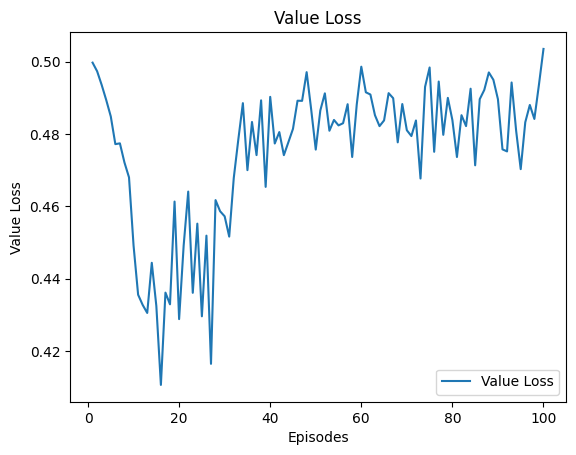

In [189]:
plt.plot(df_agents["episode"], df_agents['value_loss'], label="Value Loss")
plt.xlabel("Episodes")
plt.ylabel("Value Loss")
plt.title("Value Loss")
plt.legend()
plt.show()

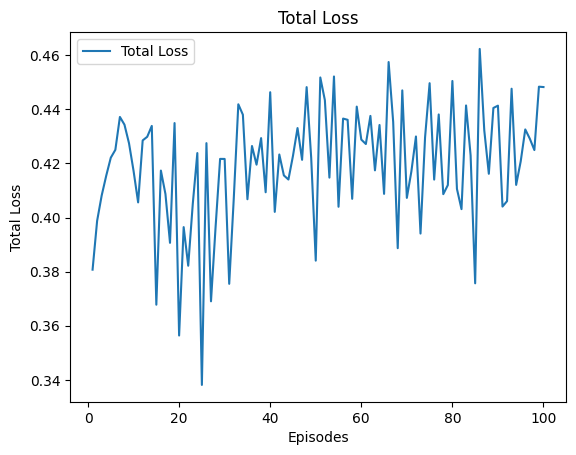

In [190]:
plt.plot(df_agents["episode"], df_agents['total_loss'], label="Total Loss")
plt.xlabel("Episodes")
plt.ylabel("Total Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

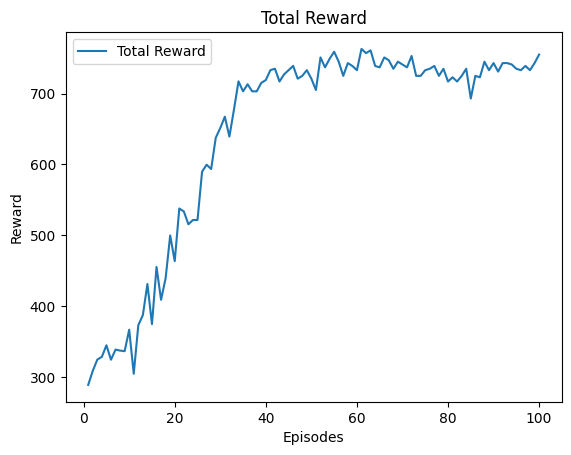

In [191]:
plt.plot(df_episode["episode"], df_episode['total_reward'], label="Total Reward")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("Total Reward")
plt.legend()
plt.show()